# Notebook 05 - CLV Prediction (Regression)

**Input:** `data/processed/customer_segments.parquet` (5,265 customers x 45 columns)

**Output:**
- `data/processed/clv_predictions.parquet` - each customer with their predicted 90-day revenue
- `models/clv_xgboost.joblib` - the trained model for later use in the API
- `reports/figures/clv_*.png` - Visualization for the boss pitch

## What we're doing and why

We're training a supervised regression model to predict **how much each customer will generate in the next 90 days**, given their behavior up to the snapshot date.

This is the project's first "real" ML model. Everything before was preparation; from here on, we're using the features to make actual predictions about the future.

## The target shape is unusual - this matters

Looking at `target_revenue_90d`:
- **56.5% of customers have target = £0** (they didn't repurchase in the window)
- **The max is £168,470** while the median is £0

This is **zero-inflated, right-skewed target**. Two consequences:
1. **We log-transform the target** so the model sees a more normal distribution
2. **We evaluate on ranking, not just absolute accuracy** - business cares about identifying *which* customers will spend, not predicting exact pounds.

## Why XGBoost
- Handles non-linear feature interaction automatically
- Robust to outliers and skewed features
- Doesn't require feature scaling
- Industry-standard for tabular data - what boss/manager expects to see
- SHAP intergration for explainability ("why did the model predict £247 for this customer?")

## Notebook structure:
1. Load and prepare features + target
2. Train/validation split (with stratification on the zero target)
3. Baseline model (so we know what "good" looks like)
4. XGBoost training
5. Eveluation - regresion metrics AND ranking metrics
6. Lift chart (the business-facing accuracy measure)
7. Feature importance with SHAP
8. Individual customer explanations
9. Save prediction and model

## Setup

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.dummy import DummyRegressor
import xgboost as xgb
import shap

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
sns.set_style('whitegrid')

PROCESSED_DIR = Path('../data/processed')
MODELS_DIR = Path('../models')
REPORTS_DIR = Path('../reports/figures')
MODELS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE=42

## 1. Load data and inspect the target

Loaded 5,256 customers x 45 columns


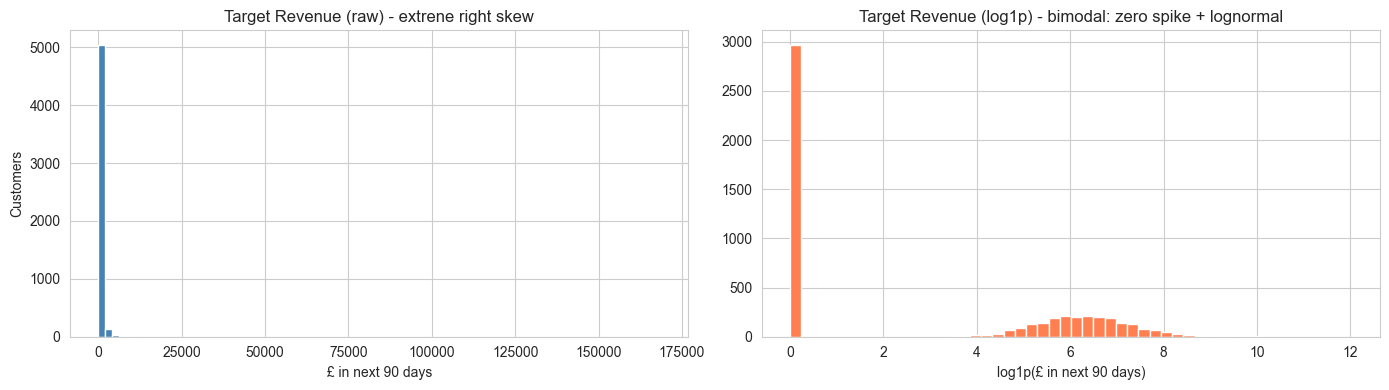


Zero-revenue customers: 2,967 (56.4%)


In [2]:
df = pd.read_parquet(PROCESSED_DIR / 'customer_segments.parquet')
print(f'Loaded {len(df):,} customers x {df.shape[1]} columns')

# Look at the target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['target_revenue_90d'], bins=80, color='steelblue', edgecolor='white')
axes[0].set_title('Target Revenue (raw) - extrene right skew')
axes[0].set_xlabel('£ in next 90 days')
axes[0].set_ylabel('Customers')

# Log-transformed view
log_target = np.log1p(df['target_revenue_90d'])
axes[1].hist(log_target, bins=50, color='coral', edgecolor='white')
axes[1].set_title('Target Revenue (log1p) - bimodal: zero spike + lognormal')
axes[1].set_xlabel('log1p(£ in next 90 days)')
plt.tight_layout()
plt.show()

print(f'\nZero-revenue customers: {(df["target_revenue_90d"] == 0).sum():,} ({(df["target_revenue_90d"] == 0).mean()*100:.1f}%)')

**Reading the plots:**
- Left: raw target - a tiny number of mega-customers visually dominate. Useless distribution shape for modeling.
- Right: log1p-transformed target - clearly bimodal. The big spike at log1p(0)=0 is churned customers. The bulge to the right is the actual revenue distribution among repeat buyers.

**Why this matters:** Linear models would fail badly on the raw target. Tree models (XGBoost) handle it better but still benefit from log-transform<br> because it stabilizes the loss surface and prevents whales from dominating gradient updates.

## 2. Prepare features and target
We use all engineered features EXCEPT:
- The targets themselves (obvious leakage)
- The customer ID (just a label, no information)
- Country name (we have `is_uk` already; we'll skip the high-cardinality categorical for now to keep things simple)
- `RFM_score` string (we have the individual R/F/M scores)
- `cluster_name` string (we have `kmeans_cluster` integer)
- `segment` string (we'll encode this since it's a useful feature)

In [3]:
EXCLUDE_COLS = {
    'CustomerID', 'primary_country', 'RFM_score', 'cluster_name', 
    'target_revenue_90d', 'target_orders_90d', 'target_purchased_90d'
}

# One-hot encode the segment column (it's categorical and meaningful)
df_encoded = pd.get_dummies(df, columns=['segment'], prefix='segment')

# Build the feature list
feature_cols = [c for c in df_encoded.columns if c not in EXCLUDE_COLS]
X = df_encoded[feature_cols].copy()
y = df_encoded['target_revenue_90d'].copy()
y_log = np.log1p(y)     # log-transformed target the model will fit

print(f'Features: {X.shape[1]} columns')
print(f'Customers: {X.shape[0]:,}')
print(f'Target stats - raw:')
print(f'    Mean: £{y.mean():,.2f}  Median: £{y.median():.2f}   Max: £{y.max():,.2f}')

Features: 46 columns
Customers: 5,256
Target stats - raw:
    Mean: £570.81  Median: £0.00   Max: £168,469.60


## 3.Train/test split with stratification
Standard 80/20 split. But here's a subtlety: since 56% of customers have target=0, a naive random split could accidentally put more zeros<br>
in one set than the other, causing weird eveluation. We **stratification on whether target > 0** to keep the zero/non-zero ratio identical in train and test

In [4]:
stratify_flag = (y > 0).astype(int)
X_train, X_test, y_train, y_test, y_train_log, y_test_log = train_test_split(
    X, y, y_log,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=stratify_flag
)

print(f'Train:  {len(X_train):,} customers ({(y_train > 0).mean()*100:.1f}% with positive target)')
print(f'Test:   {len(X_test):,} customers ({(y_test > 0).mean()*100:.1f}% with positive target)')

Train:  4,204 customers (43.6% with positive target)
Test:   1,052 customers (43.5% with positive target)


## 4. Baseline model
**Always train a dumb baseline first.** It tells what "good" looks like. If your fancy model can't beat the baseline meaningfully, something's wrong - either the features lack signal or there's a bug.

We'll use the median as the baseline prediction. With 56% zeros, the median is £0 - so the baseline literally predicts "this customer will spend £0" for everyone.

In [6]:
baseline = DummyRegressor(strategy='median')
baseline.fit(X_train, y_train)
y_pred_baseline = baseline.predict(X_test)

mae_baseline = mean_absolute_error(y_test, y_pred_baseline)
rmse_baseline = np.sqrt(mean_squared_error(y_test, y_pred_baseline))

print(f'Baseline (predict median = £{baseline.constant_[0][0]:.2f} for everyone):')
print(f'    MAE:    £{mae_baseline:,.2f}')
print(f'    RMSE:   £{rmse_baseline:,.2f}')

Baseline (predict median = £0.00 for everyone):
    MAE:    £454.21
    RMSE:   £1,658.23


**Interpreting baseline:**
- MAE = average absolute error in £. If MAE is £600, predictions are off by £600 on average.
- RMSE penalizes large errors more heavily. RMSE >> MAE mean there are some very large errors (likely whale customers).

Our XGBoost needs to beat both of these meaninfully.

## 5. Train XGBoost 
**Why we fit on `y_log` not `y` directly:** The log transform compresses the wide range of target values, so the model's loss function isn't dominated by a handful of mega-customers. We'll undo the transform with `expm1` when making predictions.

**Hyperparameter**: These are reasonable staring values. You can tune them later with Optuna or grid search if you want to squeeze out more performance, but defaults often get you 90% of the way.

In [7]:
model = xgb.XGBRegressor(
    n_estimators=300,               # number of trees
    max_depth=5,                    # Tree depth (higher = more complex, more overfit risk)
    learning_rate=0.05,             # smaller = needs more trees but more stable
    subsample=0.8,                  # row sampling per tree (reduces overfit)
    colsample_bytree=0.8,           # column sampling per tree (reduces overfit)
    min_child_weight=3,             # min samples per leaf (reduces overfit)
    objective='reg:squarederror',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    early_stopping_rounds=20,
    eval_metric='rmse'
)

# Fit on log-transformed target with eval set for early stopping
model.fit(
    X_train, y_train_log,
    eval_set=[(X_test, y_test_log)],
    verbose=1
)

print(f'Trained. Best iteration: {model.best_iteration}')
print(f'Best RMSE on log scale: {model.best_score:.4f}')

[0]	validation_0-rmse:3.13680
[1]	validation_0-rmse:3.08555
[2]	validation_0-rmse:3.03826
[3]	validation_0-rmse:2.99418
[4]	validation_0-rmse:2.95549
[5]	validation_0-rmse:2.91710
[6]	validation_0-rmse:2.88454
[7]	validation_0-rmse:2.85305
[8]	validation_0-rmse:2.82527
[9]	validation_0-rmse:2.79754
[10]	validation_0-rmse:2.77326
[11]	validation_0-rmse:2.75288
[12]	validation_0-rmse:2.73323
[13]	validation_0-rmse:2.71389
[14]	validation_0-rmse:2.69518
[15]	validation_0-rmse:2.68070
[16]	validation_0-rmse:2.66601
[17]	validation_0-rmse:2.65275
[18]	validation_0-rmse:2.64147
[19]	validation_0-rmse:2.63106
[20]	validation_0-rmse:2.62205
[21]	validation_0-rmse:2.61353
[22]	validation_0-rmse:2.60598
[23]	validation_0-rmse:2.60024
[24]	validation_0-rmse:2.59228
[25]	validation_0-rmse:2.58478
[26]	validation_0-rmse:2.57880
[27]	validation_0-rmse:2.57329
[28]	validation_0-rmse:2.56815
[29]	validation_0-rmse:2.56246
[30]	validation_0-rmse:2.55732
[31]	validation_0-rmse:2.55240
[32]	validation_0-

## 6. Generate predictions on the test set

Predictions come back in log space; we invert with `expm1` to get back to pounds. We also clip nagative prediction to 0 (you can't predict negative revenue)

In [8]:
y_pred_log = model.predict(X_test)
y_pred = np.clip(np.expm1(y_pred_log), 0, None)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print('XGBoost performance:')
print(f'    MAE:    £{mae:,.2f} (baseline: £{mae_baseline:,.2f}, improvement: £{(mae_baseline - mae)/mae_baseline*100:.1f}%)')
print(f'    RMSE:   £{rmse:,.2f} (baseline: £{rmse_baseline:,.2f}, improvement: {(rmse_baseline-rmse)/rmse_baseline*100:.1f}%)')
print(f'    R2:     {r2:.3f} (1.0 = perfect, 0 = no better then mean)')

XGBoost performance:
    MAE:    £353.09 (baseline: £454.21, improvement: £22.3%)
    RMSE:   £1,249.46 (baseline: £1,658.23, improvement: 24.7%)
    R2:     0.386 (1.0 = perfect, 0 = no better then mean)


**How to read these numbers honestly:**
- **MAE improvement** is the most digestible - "the model is X% more accurate on average than guessing the median."
- **R²** measures how much variance the model explains. For e-commerce with heavy zero-inflation, R² of 0.3-0.5 is realistic. Don't expect 0.9 - that would be suspicious (likely leakage).
- **RMSE > MAE** by a lot means whales hurt the model. Expected with this data shape.

**Now the more useful question:** Is the model good at *ranking* customers? Because the business doesn't care if predict £247 vs £253 - they care about identifying the top 20% of customers to target.

## 7. Predicted vs. actual scatter plot
Quick visual check that predictions correlate with reality. We plot on log scale because of the skew.

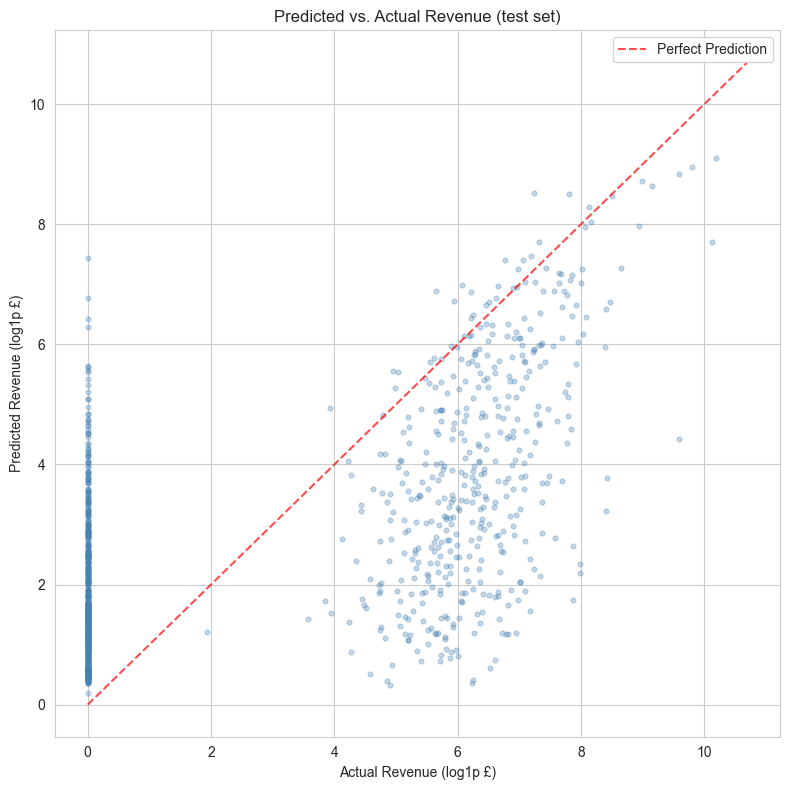

In [9]:
fig, ax = plt.subplots(figsize=(8,8))
ax.scatter(np.log1p(y_test), np.log1p(y_pred), alpha=0.3, s=12, color='steelblue')
lims = [0, max(np.log1p(y_test).max(), np.log1p(y_pred).max()) + 0.5]
ax.plot(lims, lims, 'r--', alpha=0.7, label='Perfect Prediction')
ax.set_xlabel('Actual Revenue (log1p £)')
ax.set_ylabel('Predicted Revenue (log1p £)')
ax.set_title('Predicted vs. Actual Revenue (test set)')
ax.legend()
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'clv_pred_vs_actual.png', dpi=120, bbox_inches='tight')
plt.show()

**Reading the scatter:**
- The dense column at x=0 is the churned customers (true revenue = £0). The model rarely predicts exactly 0 - it predicts "a small amount" for them, which is fine
- Points above the diagonal = under-predicted (model said low, customer actually spent a lot)
- Points below the diagonal = over-predicted
- The cloud should be roughly diagonal - that's the ranking signal

## 8. Lift chart - the business-facing accuracy measure

**This is THE chart for your manager/boss.** It answers: "If we rank customers by predicted CLV and target the top X%, how much of the actual future revenue would we capture?"

- Perfect ranking: target top 10% -> capture 100% of revenue (impossible in practice)
- Random ranking: target top 10% -> capture 10% of revenue (the diagonal baseline)
- Our model: somewhere in between, hopefully much closer to perfect

**The area between out curve and the diagonal is the business value of the model**

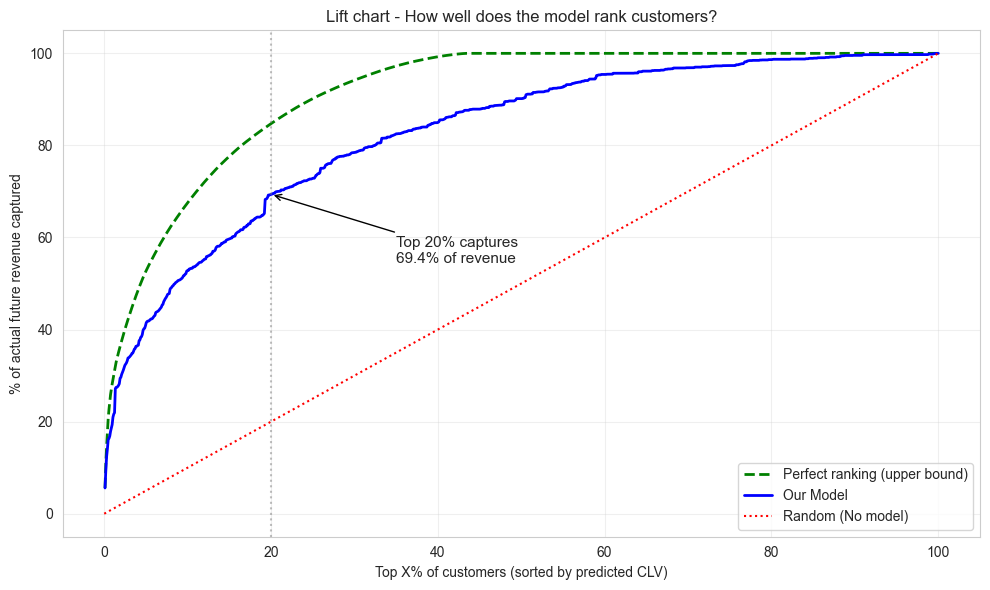


Key numbers for the pitch:
    Top 10% of customers -> captures 52.8% of future revenue
    Top 20% of customers -> captures 69.4% of future revenue
    Top 30% of customers -> captures 78.5% of future revenue
    Top 50% of customers -> captures 90.2% of future revenue


In [10]:
# Sort by predicted, see cumulative capture of actual revenue
sort_idx = np.argsort(-y_pred)  # descending by prediction
actual_sorted = y_test.values[sort_idx]

cumulative_revenue = np.cumsum(actual_sorted) / actual_sorted.sum()
cumulative_customers = np.arange(1, len(actual_sorted) + 1) / len(actual_sorted)

# Perfect ranking (sort actuals descending)
perfect_sorted = np.sort(y_test.values)[::-1]
cumulative_perfect = np.cumsum(perfect_sorted) / perfect_sorted.sum()

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(cumulative_customers * 100, cumulative_perfect * 100, 'g--',
        label='Perfect ranking (upper bound)', linewidth=2)
ax.plot(cumulative_customers * 100, cumulative_revenue * 100, 'b-',
        label='Our Model', linewidth=2)
ax.plot([0,100],[0,100], 'r:', label="Random (No model)", linewidth=1.5)
ax.set_xlabel('Top X% of customers (sorted by predicted CLV)')
ax.set_ylabel('% of actual future revenue captured')
ax.set_title('Lift chart - How well does the model rank customers?')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

# Annotate the top-20% capture rate (a useful business number)
top_20_idx = int(0.20 * len(cumulative_revenue))
top_20_capture = cumulative_revenue[top_20_idx] * 100
ax.axvline(20, color='gray', linestyle=':', alpha=0.5)
ax.annotate(f'Top 20% captures\n{top_20_capture:.1f}% of revenue',
            xy=(20, top_20_capture), xytext=(35, top_20_capture - 15),
            fontsize=11, arrowprops=dict(arrowstyle='->', color='black'))

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'clv_lift_chart.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nKey numbers for the pitch:')
for pct in [0.10, 0.20, 0.30, 0.50]:
    idx = int(pct * len(cumulative_revenue))
    print(f'    Top {int(pct*100)}% of customers -> captures {cumulative_revenue[idx]*100:.1f}% of future revenue')

**This is the slide.** "If we focus marketing on the top 20% of customers by predicted CLV, we cover X% of future revenue. That's how we 5x our marketing ROI."

## 9. Feature importance with SHAP
**Why SHAP and not just `model.feature_importance_`?** XGBoost's built-in importance tells you *which features the model used*, but not *how* or *in what direction*.<br>
SHAP gives you signed, per-prediction explanations: "this featurepushed the prediction UP by £150 for this customer."

SHAP is the standard for tabular ML explainability in 2024-2026. Knowing it is a real skill

In [14]:
# Compute SHAP values on test set
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

print(f'SHAP values shape: {shap_values.shape}')
print(f'(one row per test customer, one column per feature)')

SHAP values shape: (1052, 46)
(one row per test customer, one column per feature)


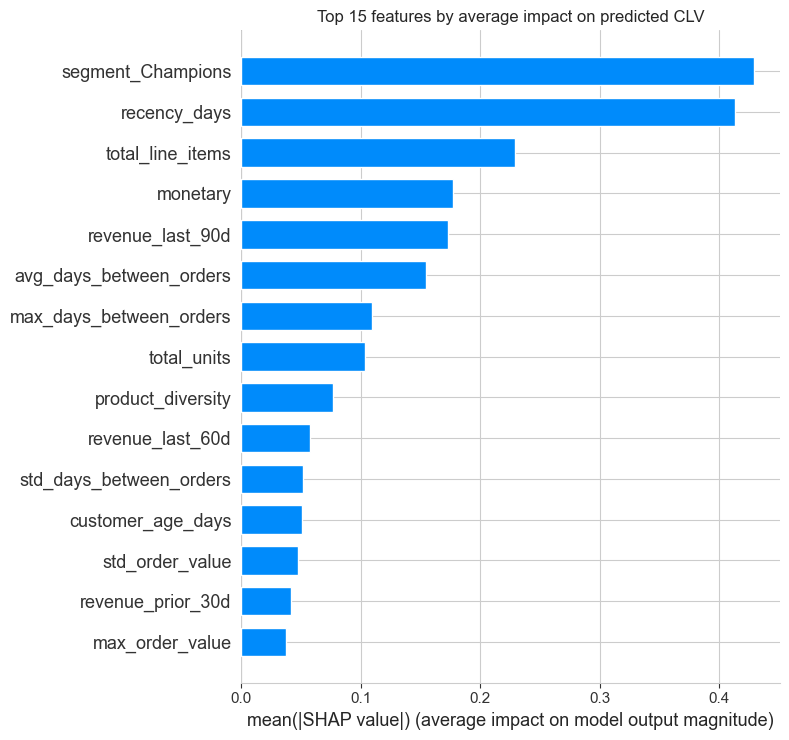

In [15]:
# Global feature importance: which features matter most on average?
fig = plt.figure(figsize=(10,8))
shap.summary_plot(shap_values, X_test, plot_type='bar', max_display=15, show=False)
plt.title('Top 15 features by average impact on predicted CLV')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'clv_shap_importance.png', dpi=120, bbox_inches='tight')
plt.show()

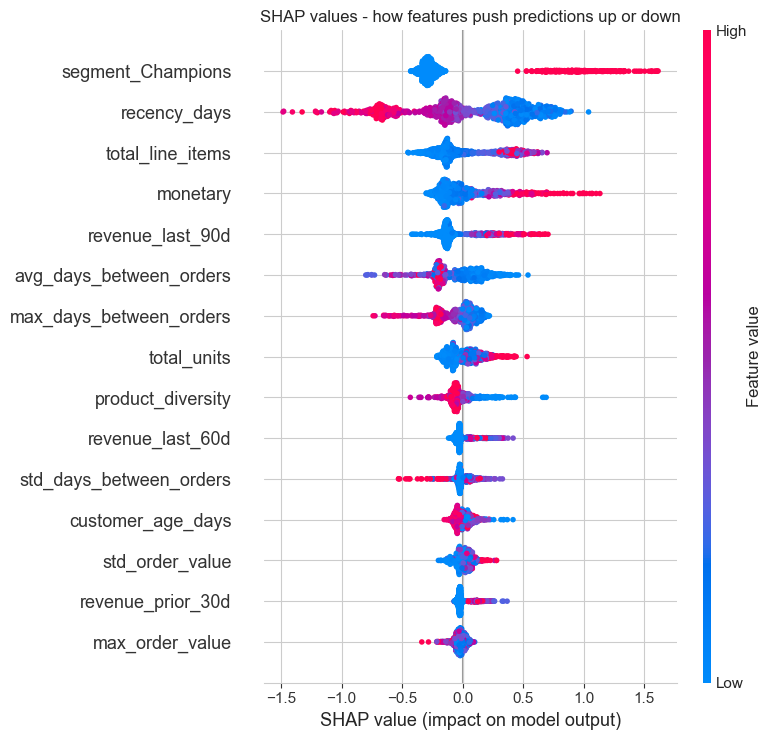

In [16]:
# Beeswarm plot: shows both magnitude AND direction
fig = plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, max_display=15, show=False)
plt.title('SHAP values - how features push predictions up or down')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'clv_shap_beeswarm.png', dpi=120, bbox_inches='tight')
plt.show()

**Reading the beeswarm**:
- Each dot is one customer
- Position on x-axis = how much that feature pusheded the prediction (right = pushed UP, left = pushed DOWN)
- Color = the feature's value (red = high, blue = low)

**Patterns to look for:**
- For `monetary`: red dots (high spenders) should be on the right (prediction pushed up) ✅ expected
- For `recency_days`: red dots (long recency) should be on the left (prediction pushed down) ✅ expected
- If you see the opposite, that's a bug or surprising insight

## 10. Per-customer explanations

For any individual customer, SHAP can show exactly which feature drove their prediction. This is gold for the recommendations notebook later.

Let's pick a few interesting test customers and explain each:

In [21]:
# Pick: a high-predicted customer, a low-predicted customer, and a surprising one
test_results = pd.DataFrame({
    'actual': y_test.values,
    'predicted': y_pred
}, index=X_test.index)

high_pred_idx = test_results['predicted'].idxmax()
low_pred_idx = test_results[test_results['predicted'] > 0]['predicted'].idxmin()

for label, idx in [('Highest predicted CLV', high_pred_idx), ('Lowest non-zero predicted CLV', low_pred_idx)]:
    print(f'\n=== {label} ===')
    print(f'    Predicted:  £{test_results.loc[idx, "predicted"]:,.2f}')
    print(f'    Actual:     £{test_results.loc[idx, "actual"]:,.2f}')
    row_position = X_test.index.get_loc(idx)
    contributions = pd.Series(shap_values[row_position], index=X_test.columns).sort_values(key=abs, ascending=False)
    print(f'    Top 5 drivers of this prediction:')
    for feat, contrib in contributions.head(5).items():
        direction = '⬆️' if contrib > 0 else '⬇️'
        print(f'    - {direction} {feat}: SHAP impact = {contrib:+.3f} (log scale), customer value = {X_test.loc[idx,feat]}')


=== Highest predicted CLV ===
    Predicted:  £8,961.64
    Actual:     £26,720.70
    Top 5 drivers of this prediction:
    - ⬆️ segment_Champions: SHAP impact = +1.606 (log scale), customer value = True
    - ⬆️ monetary: SHAP impact = +1.133 (log scale), customer value = 87345.69
    - ⬆️ revenue_last_90d: SHAP impact = +0.660 (log scale), customer value = 17557.88
    - ⬆️ recency_days: SHAP impact = +0.519 (log scale), customer value = 3
    - ⬆️ total_units: SHAP impact = +0.424 (log scale), customer value = 41803

=== Lowest non-zero predicted CLV ===
    Predicted:  £0.22
    Actual:     £0.00
    Top 5 drivers of this prediction:
    - ⬇️ recency_days: SHAP impact = -1.484 (log scale), customer value = 418
    - ⬇️ revenue_last_90d: SHAP impact = -0.412 (log scale), customer value = 0.0
    - ⬇️ segment_Champions: SHAP impact = -0.375 (log scale), customer value = False
    - ⬆️ total_line_items: SHAP impact = +0.293 (log scale), customer value = 177
    - ⬇️ std_days_between

**This output is what makes the recommendation engine in Notebook 08 possible**. Instead of just saying "customer 12345 has predicted CLV of £247",<br>
we can say "customer 12345 has predicted CLV of £247 because they bough recently (⬆️), have high frequency (⬆️), and ordered diverse products (⬆️)." <br>
That's an explanation a marketing team can act on.

## 11. Generate predictions for ALL customers and save

For the recommendation engine, we need predicted CLV for every customer, not kust the test set. We re-predict on the full feature set.

In [22]:
y_all_pred_log = model.predict(X)
y_all_pred = np.clip(np.expm1(y_all_pred_log), 0, None)

predictions = pd.DataFrame({
    'CustomerID': df['CustomerID'].values,
    'segment': df['segment'].values,
    'monetary': df['monetary'].values,
    'predicted_clv_90d': y_all_pred,
    'actual_revenue_90d': y.values,
})
predictions = predictions.sort_values('predicted_clv_90d', ascending=False).reset_index(drop=True)
predictions['clv_rank'] = predictions.index + 1
predictions['clv_decile'] = pd.qcut(predictions['predicted_clv_90d'].rank(method='first'), 10, labels=list(range(10, 0, -1))).astype(int)

print('Predicted CLV by segment (descending):')
predictions.groupby('segment').agg(
    customers=('CustomerID', 'count'),
    avg_predicted_clv=('predicted_clv_90d', 'mean'),
    total_predicted_clv=('predicted_clv_90d', 'sum')
).sort_values('total_predicted_clv', ascending=False).round(2)

Predicted CLV by segment (descending):


,customers,avg_predicted_clv,total_predicted_clv
segment,,,
Champions,1203,694.340027,835285.812500
Loyal Customers,923,40.240002,37143.558594
Need Attention,1087,7.320000,7955.189941
Potential Loyalists,214,31.950001,6837.609863
New Customers,170,26.090000,4434.660156
Cannot Lose Them,216,16.639999,3594.919922
At Risk,364,7.140000,2599.719971
Hibernating,414,2.610000,1079.800049
Lost,665,0.960000,640.969971


In [23]:
predictions.head(15)

,CustomerID,segment,monetary,predicted_clv_90d,actual_revenue_90d,clv_rank,clv_decile
0,18102.0,Champions,484615.10,16937.779297,124206.55,1,1
1,14646.0,Champions,425343.12,15357.001953,101408.40,2,1
2,17450.0,Champions,138883.84,14978.874023,108089.25,3,1
3,17511.0,Champions,143916.92,13661.347656,31686.63,4,1
4,16684.0,Champions,114372.71,13263.460938,32770.06,5,1
5,14156.0,Champions,285257.34,11416.822266,18321.29,6,1
6,13694.0,Champions,177354.83,10494.423828,19127.98,7,1
7,12931.0,Champions,82822.08,9190.161133,9525.26,8,1
8,15838.0,Champions,54673.42,9033.619141,19489.58,9,1
9,14911.0,Champions,216557.23,8989.388672,60097.38,10,1
